# MetaAlgorithmGA Testing Notebook

This notebook demonstrates how to use the MetaAlgorithmGA to optimize matching on graphs, including large 1K-node graphs.

## Setup & Imports

In [1]:
import sys

from meta.core import CanonicalVector, FitnessEvaluator, MetaAlgorithmGA

sys.path.insert(0, '..')

from src.graph.graph_manager import GraphManager
from tests.fixtures.graphs import (
    CLUSTERED_GRAPH_1K, RANDOM_DENSE_GRAPH_1K, SCALE_FREE_GRAPH_1K,
    BIPARTITE_GRAPH_1K, GRID_4x4, K5_CLUSTERS, STAR_WITH_TAIL,CLUSTERED_GRAPH_500,
CLUSTERED_GRAPH_100
)
import matplotlib.pyplot as plt
import numpy as np

## Helper Functions

In [2]:
def fixture_to_graph(fixture_dict) -> GraphManager:
    """Convert fixture dictionary to GraphManager."""
    graph = GraphManager.create_empty_graph()
    
    # Add vertices
    for v in fixture_dict['vertices']:
        graph.add_vertex(v)
    
    # Add edges
    for u, v, w in fixture_dict['edges']:
        graph.add_edge(u, v, float(w))
    
    return graph

def evaluate_vector(graph: GraphManager, vector: CanonicalVector) -> float:
    """Quick evaluation of a vector on a graph using distributed algorithm."""
    evaluator = FitnessEvaluator()  # Now uses DistributedOrchestrator internally
    return evaluator.evaluate(graph, vector)

def run_ga_experiment(graph: GraphManager, graph_name: str, 
                      population_size: int = 15, 
                      generations: int = 8,
                      mutation_rate: float = 0.15) -> dict:
    """Run GA experiment and return results using distributed algorithm."""
    evaluator = FitnessEvaluator()  # Now uses DistributedOrchestrator internally
    ga = MetaAlgorithmGA(
        fitness_evaluator=evaluator,
        population_size=population_size,
        generations=generations,
        mutation_rate=mutation_rate
    )
    
    best_vector, fitness_history = ga.evolve(graph)
    
    # Evaluate random vector for comparison
    random_vector = CanonicalVector()
    random_fitness = evaluate_vector(graph, random_vector)
    
    return {
        'graph_name': graph_name,
        'best_vector': best_vector,
        'fitness_history': fitness_history,
        'random_fitness': random_fitness,
        'best_fitness': fitness_history[-1],
        'improvement_pct': ((fitness_history[-1] - random_fitness) / (random_fitness + 1e-10)) * 100
    }

## Test 1: Clustered Graph 1K Optimization

In [3]:
test_graph = CLUSTERED_GRAPH_100
# Load and prepare clustered graph
print(f"Loading graph...")
print(f"  Name: {test_graph['name']}")
print(f"  Vertices: {len(test_graph['vertices'])}")
print(f"  Edges: {len(test_graph['edges'])}")
print(f"  Expected optimal weight: {test_graph['optimal_weight']}")
print()

graph = fixture_to_graph(test_graph)
print(f"Graph created successfully")
print(f"  GraphManager vertices: {len(graph.vertices())}")
print(f"  GraphManager edges: {graph.num_edges()}")

Loading graph...
  Name: Clustered Graph with Communities (1000 nodes)
  Vertices: 100
  Edges: 360
  Expected optimal weight: 9375

Graph created successfully
  GraphManager vertices: 100
  GraphManager edges: 360


In [4]:
# Run GA optimization on clustered graph
print(f"\nRunning GA optimization on {test_graph['name']}...")

# First test: single vector evaluation to verify distributed algorithm
test_vector = CanonicalVector()
test_eval = FitnessEvaluator()
test_fitness = test_eval.evaluate(graph, test_vector)
print(f"  Single vector test fitness: {test_fitness:.1f}")

result = run_ga_experiment(graph, test_graph['name'],
                           population_size=15, generations=10, mutation_rate=0.15)

print("\n" + "="*70)
print(f"{test_graph['name']} - OPTIMIZATION RESULTS")
print("="*70)
print(f"Best fitness found:     {result['best_fitness']:.2f}")
print(f"Random baseline:        {result['random_fitness']:.2f}")
print(f"Improvement:            {result['improvement_pct']:+.1f}%")
print()

print("Best vector parameters:")
bv = result['best_vector']
print(f"  Luby base probability:      {bv.luby_base_probability:.3f}")
print(f"  Luby coeff degree:          {bv.luby_coeff_degree:.3f}")
print(f"  Luby coeff neighbors:       {bv.luby_coeff_neighbors_unmatched:.3f}")
print(f"  Luby coeff clustering:      {bv.luby_coeff_clustering:.3f}")
print(f"  Luby coeff matched:         {bv.luby_coeff_matched:.3f}")
print(f"  Luby coeff round:           {bv.luby_coeff_round:.3f}")
print(f"  Luby coeff weight:          {bv.luby_coeff_weight:.3f}")
print(f"  Itai timeout rounds:        {bv.itai_timeout_rounds}")
print(f"  Max iterations:             {bv.max_iterations}")
print(f"  Convergence threshold:      {bv.convergence_threshold:.4f}")


Running GA optimization on Clustered Graph with Communities (1000 nodes)...
  Single vector test fitness: 5293.0

Clustered Graph with Communities (1000 nodes) - OPTIMIZATION RESULTS
Best fitness found:     5600.00
Random baseline:        5477.00
Improvement:            +2.2%

Best vector parameters:
  Luby base probability:      0.612
  Luby coeff degree:          0.842
  Luby coeff neighbors:       -0.934
  Luby coeff clustering:      -0.651
  Luby coeff matched:         -0.445
  Luby coeff round:           -0.061
  Luby coeff weight:          0.637
  Itai timeout rounds:        9
  Max iterations:             87
  Convergence threshold:      0.0638


## Test 2: Fitness Progression (Clustered Graph)

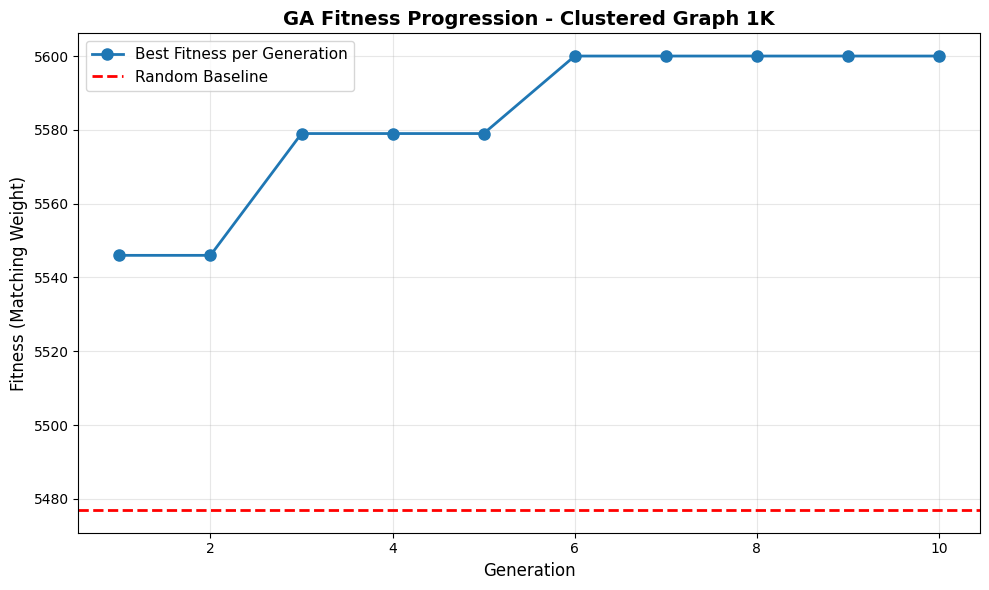

Fitness per generation:
  Gen  1: 5546.00
  Gen  2: 5546.00 → (Δ +0.00)
  Gen  3: 5579.00 ↑ (Δ +33.00)
  Gen  4: 5579.00 → (Δ +0.00)
  Gen  5: 5579.00 → (Δ +0.00)
  Gen  6: 5600.00 ↑ (Δ +21.00)
  Gen  7: 5600.00 → (Δ +0.00)
  Gen  8: 5600.00 → (Δ +0.00)
  Gen  9: 5600.00 → (Δ +0.00)
  Gen 10: 5600.00 → (Δ +0.00)


In [5]:
# Plot fitness history
history = result['fitness_history']
generations_list = list(range(1, len(history) + 1))

plt.figure(figsize=(10, 6))
plt.plot(generations_list, history, marker='o', linewidth=2, markersize=8, label='Best Fitness per Generation')
plt.axhline(y=result['random_fitness'], color='r', linestyle='--', linewidth=2, label='Random Baseline')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness (Matching Weight)', fontsize=12)
plt.title('GA Fitness Progression - Clustered Graph 1K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Fitness per generation:")
for gen, fitness in enumerate(history, 1):
    if gen == 1:
        print(f"  Gen {gen:2d}: {fitness:.2f}")
    else:
        improvement = fitness - history[gen-2]
        status = "↑" if improvement > 0.01 else "→"
        print(f"  Gen {gen:2d}: {fitness:.2f} {status} (Δ {improvement:+.2f})")

## Test 3: Compare All 1K Graphs

In [ ]:
# Test on all large 1K graphs
graph_fixtures_1k = [
    ("CLUSTERED_GRAPH_1K", CLUSTERED_GRAPH_1K),
    ("RANDOM_DENSE_GRAPH_1K", RANDOM_DENSE_GRAPH_1K),
    ("SCALE_FREE_GRAPH_1K", SCALE_FREE_GRAPH_1K),
    ("BIPARTITE_GRAPH_1K", BIPARTITE_GRAPH_1K),
]

results_1k = []

print("Running GA on all 1K graphs...\n")
for graph_name, fixture in graph_fixtures_1k:
    print(f"Processing {graph_name}...")
    graph = fixture_to_graph(fixture)
    result = run_ga_experiment(graph, graph_name, population_size=12, generations=6, mutation_rate=0.12)
    results_1k.append(result)
    print(f"  ✓ Best={result['best_fitness']:8.2f}, Random={result['random_fitness']:8.2f}, Improvement={result['improvement_pct']:+7.1f}%\n")

print()

Running GA on all 1K graphs...

Processing CLUSTERED_GRAPH_1K...
  ✓ Best=53600.00, Random=51775.00, Improvement=   +3.5%

Processing RANDOM_DENSE_GRAPH_1K...
  ✓ Best=51423.00, Random=49039.00, Improvement=   +4.9%

Processing SCALE_FREE_GRAPH_1K...


## Test 4: 1K Graphs Comparison Visualization

NameError: name 'results_1k' is not defined

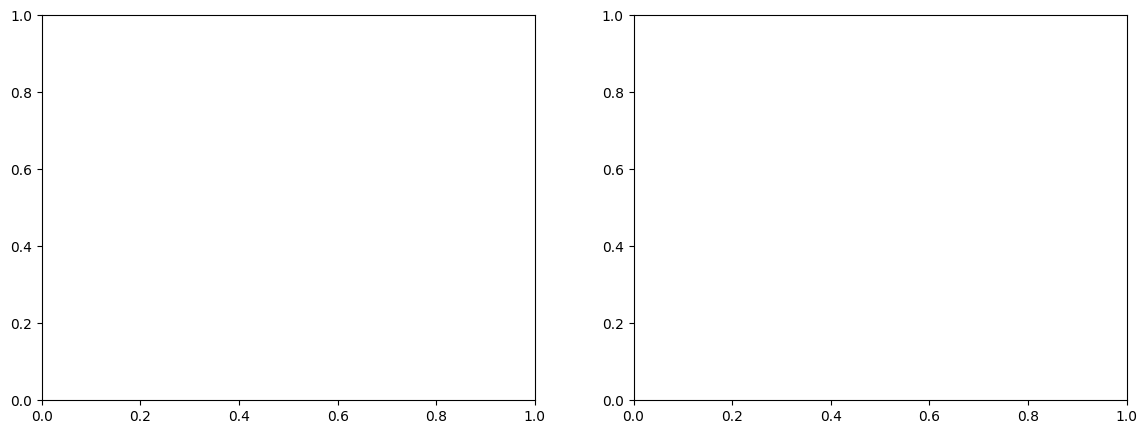

In [4]:
# Compare results across 1K graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best vs Random fitness
graph_names = [r['graph_name'] for r in results_1k]
best_fits = [r['best_fitness'] for r in results_1k]
random_fits = [r['random_fitness'] for r in results_1k]

x = np.arange(len(graph_names))
width = 0.35

axes[0].bar(x - width/2, best_fits, width, label='GA Optimized', alpha=0.8)
axes[0].bar(x + width/2, random_fits, width, label='Random', alpha=0.8)
axes[0].set_xlabel('Graph Type', fontsize=11)
axes[0].set_ylabel('Fitness', fontsize=11)
axes[0].set_title('GA vs Random Baseline (1K Graphs)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([name.replace('_GRAPH_1K', '') for name in graph_names], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Improvement percentage
improvements = [r['improvement_pct'] for r in results_1k]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

axes[1].bar([name.replace('_GRAPH_1K', '') for name in graph_names], improvements, color=colors, alpha=0.7)
axes[1].set_xlabel('Graph Type', fontsize=11)
axes[1].set_ylabel('Improvement (%)', fontsize=11)
axes[1].set_title('GA Improvement vs Random (1K Graphs)', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Test 5: Small Graphs Comparison

In [ ]:
# Test on small graphs for baseline comparison
graph_fixtures_small = [
    ("GRID_4x4", GRID_4x4),
    ("K5_CLUSTERS", K5_CLUSTERS),
    ("STAR_WITH_TAIL", STAR_WITH_TAIL),
]

results_small = []

print("Running GA on small graphs for comparison...\n")
for graph_name, fixture in graph_fixtures_small:
    print(f"Processing {graph_name}...")
    graph = fixture_to_graph(fixture)
    result = run_ga_experiment(graph, graph_name, population_size=10, generations=8, mutation_rate=0.15)
    results_small.append(result)
    print(f"  ✓ Best={result['best_fitness']:8.2f}, Random={result['random_fitness']:8.2f}, Improvement={result['improvement_pct']:+7.1f}%\n")

print()

## Test 6: Convergence Analysis on 1K Graph

In [ ]:
# Extended convergence test on clustered graph
print("Running extended convergence analysis (20 generations)...")
graph = fixture_to_graph(CLUSTERED_GRAPH_1K)
result = run_ga_experiment(graph, "CLUSTERED_1K_EXTENDED", 
                           population_size=15, generations=20, mutation_rate=0.15)

history = result['fitness_history']
generations_list = list(range(1, len(history) + 1))

# Calculate convergence metrics
improvements = [history[i] - history[i-1] if i > 0 else 0 for i in range(len(history))]
converged_gen = next((i for i, imp in enumerate(improvements[1:], 1) if imp < 0.01), len(improvements))

print(f"\nConvergence Analysis (20 generations):")
print(f"  Best fitness: {history[-1]:.2f}")
print(f"  Converged at generation: {converged_gen}")
print(f"  Total improvement: {history[-1] - history[0]:.2f}")
print()

In [ ]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness history
axes[0].plot(generations_list, history, marker='o', linewidth=2, markersize=6)
axes[0].axvline(x=converged_gen, color='red', linestyle='--', alpha=0.7, label=f'Convergence (Gen {converged_gen})')
axes[0].set_xlabel('Generation', fontsize=11)
axes[0].set_ylabel('Fitness', fontsize=11)
axes[0].set_title('Fitness Progression - Extended (Clustered 1K)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Improvements per generation
axes[1].bar(generations_list, improvements, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Generation', fontsize=11)
axes[1].set_ylabel('Improvement', fontsize=11)
axes[1].set_title('Generation-to-Generation Improvement', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()